# OASIS-2 Coronal 2-Qubit Diagnostic Analysis

Research notebook for the OASIS-2 coronal experiment comparing a classical CNN against a 2-qubit hybrid classical-quantum model. The notebook uses saved CSV outputs so the results can be inspected without rerunning training.

## Result Summary

- Classical CNN converged in 8/10 trials and was stuck in 2/10 trials.
- Hybrid CQ-CNN at baseline `lr=0.001` converged in 5/10 trials and was stuck in 5/10 trials.
- The hybrid model showed higher seed sensitivity and lower mean performance than the classical baseline.
- Hybrid QNN gradient norms did not collapse to zero in stuck trials.
- Stuck hybrid trials showed smaller QNN weight-update magnitudes, especially at the final epoch.
- The learning-rate sweep suggests optimizer sensitivity: `lr=0.0005` reduced the hybrid stuck rate to 30%, while `lr=0.002` produced the best mean macro F1 but still had a 50% stuck rate.
- Interpretation: the result supports the paper's claim that hybrid models can get stuck during optimization, but our run points to ineffective quantum parameter updates and optimizer sensitivity rather than simple zero-gradient collapse.

In [37]:
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "classification":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_SCRIPT = PROJECT_ROOT / "experiments/oasis2/oasis2_coronal_experiment.py"
RESULT_DIR = PROJECT_ROOT / "results/classification/oasis2_coronal_128_64"
CLASSICAL_CSV = RESULT_DIR / "oasis2_coronal_2qubit_classical.csv"
HYBRID_CSV = RESULT_DIR / "oasis2_coronal_2qubit_hybrid.csv"
DIAGNOSTICS_CSV = RESULT_DIR / "oasis2_coronal_2qubit_hybrid_diagnostics.csv"
LR_SWEEP_DIR = RESULT_DIR / "lr_sweep"
LR_SWEEP_SUMMARY_CSV = LR_SWEEP_DIR / "hybrid_lr_sweep_summary.csv"

EXPECTED_TRIALS = 10
FAILURE_MACRO_F1_THRESHOLD = 0.40
FAILURE_BALANCED_ACC_THRESHOLD = 0.55

PROJECT_ROOT, RESULT_DIR

(PosixPath('/Users/mustakimahmedhasan/Workspace/Research/Code/cq-cnn-alzheimer/cqcnn-reimplementation-clean'),
 PosixPath('/Users/mustakimahmedhasan/Workspace/Research/Code/cq-cnn-alzheimer/cqcnn-reimplementation-clean/results/classification/oasis2_coronal_128_64'))

## Experiment Setup

This table captures the fixed baseline setting used for the saved experiment outputs.

In [38]:
setup_table = pd.DataFrame([
    {"setting": "Dataset", "value": "OASIS-2"},
    {"setting": "Plane", "value": "Coronal"},
    {"setting": "Classes", "value": "nondemented vs moderate_dementia"},
    {"setting": "Models", "value": "Classical CNN, 2-qubit hybrid CQ-CNN"},
    {"setting": "Qubits", "value": 2},
    {"setting": "Trials", "value": EXPECTED_TRIALS},
    {"setting": "Seeds", "value": "42, 43, 44, 45, 46, 47, 48, 49, 50, 51"},
    {"setting": "Epochs", "value": 10},
    {"setting": "Train limit", "value": 128},
    {"setting": "Test limit", "value": 64},
    {"setting": "Batch size", "value": 8},
    {"setting": "Learning rate", "value": 0.001},
    {"setting": "Stuck threshold", "value": "macro F1 <= 0.40 or balanced accuracy <= 0.55"},
])
setup_table

,setting,value
0,Dataset,OASIS-2
1,Plane,Coronal
2,Classes,nondemented vs moderate_dementia
3,Models,"Classical CNN, 2-qubit hybrid CQ-CNN"
4,Qubits,2
5,Trials,10
6,Seeds,"42, 43, 44, 45, 46, 47, 48, 49, 50, 51"
7,Epochs,10
8,Train limit,128
9,Test limit,64


## Optional: Refresh Experiment

`RUN_EXPERIMENT` stays `False` by default. Leave it off when reviewing the saved baseline results.

In [39]:
RUN_EXPERIMENT = False

if RUN_EXPERIMENT:
    command = [sys.executable, str(EXPERIMENT_SCRIPT)]
    completed = subprocess.run(command, cwd=PROJECT_ROOT, text=True, capture_output=True)
    print(completed.stdout)
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError(f"Experiment failed with exit code {completed.returncode}")

## Load Saved Outputs

The classical and hybrid performance CSVs are required. The diagnostics CSV is optional but expected for this artifact.

In [40]:
missing = [path for path in [CLASSICAL_CSV, HYBRID_CSV] if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing result CSVs: {missing}. Run the experiment first.")

classical = pd.read_csv(CLASSICAL_CSV)
hybrid = pd.read_csv(HYBRID_CSV)
diagnostics_df = pd.read_csv(DIAGNOSTICS_CSV) if DIAGNOSTICS_CSV.exists() else pd.DataFrame()
lr_sweep_summary = pd.read_csv(LR_SWEEP_SUMMARY_CSV) if LR_SWEEP_SUMMARY_CSV.exists() else pd.DataFrame()
results = pd.concat([classical, hybrid], ignore_index=True)

epoch_df = results[results["row_type"] == "epoch"].copy()
final_df = results[results["row_type"] == "final"].copy()
summary_df = results[results["row_type"] == "summary"].copy()

numeric_cols = [
    "trial", "seed", "epoch", "train_loss", "train_acc", "test_loss", "test_acc",
    "test_macro_f1", "test_balanced_acc", "precision", "recall", "f1", "macro_f1",
    "balanced_acc", "auc", "sensitivity", "specificity", "tn", "fp", "fn", "tp",
    "failure_count", "success_count", "failure_rate",
    "qnn_grad_norm", "qnn_weight_update_norm", "fc2_grad_norm", "fc2_weight_update_norm",
    "fc3_grad_norm", "fc3_weight_update_norm",
]
for frame in [epoch_df, final_df, summary_df, diagnostics_df]:
    for col in numeric_cols:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

original_final = final_df[final_df["eval_split"] == "original"].copy()
if "convergence_status" not in original_final.columns:
    original_final["convergence_status"] = original_final.apply(
        lambda row: "stuck" if row["macro_f1"] <= FAILURE_MACRO_F1_THRESHOLD or row["balanced_acc"] <= FAILURE_BALANCED_ACC_THRESHOLD else "converged",
        axis=1,
    )

print(f"Epoch rows: {len(epoch_df)}")
print(f"Final rows: {len(final_df)}")
print(f"Summary rows: {len(summary_df)}")
print(f"Diagnostics rows: {len(diagnostics_df)}")
print(f"LR sweep rows: {len(lr_sweep_summary)}")
display(original_final.groupby("model")["trial"].nunique().rename("original_test_trials").to_frame())

Epoch rows: 200
Final rows: 40
Summary rows: 8
Diagnostics rows: 100
LR sweep rows: 3


,original_test_trials
model,
classical,10
hybrid,10


## Performance Comparison

The primary comparison uses original-test macro F1, balanced accuracy, AUC, and test loss averaged across the 10 seeds.

In [41]:
performance_summary = (
    original_final.groupby("model")
    .agg(
        trials=("trial", "nunique"),
        mean_test_acc=("test_acc", "mean"),
        std_test_acc=("test_acc", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_balanced_acc=("balanced_acc", "mean"),
        std_balanced_acc=("balanced_acc", "std"),
        mean_auc=("auc", "mean"),
        mean_test_loss=("test_loss", "mean"),
    )
    .sort_values("mean_macro_f1", ascending=False)
)
performance_summary.round(4)

,trials,mean_test_acc,std_test_acc,mean_macro_f1,std_macro_f1,mean_balanced_acc,std_balanced_acc,mean_auc,mean_test_loss
model,,,,,,,,,
classical,10,0.7641,0.1688,0.7299,0.2300,0.7641,0.1688,0.8659,0.4940
hybrid,10,0.6734,0.2056,0.5895,0.2861,0.6734,0.2056,0.7261,0.6274


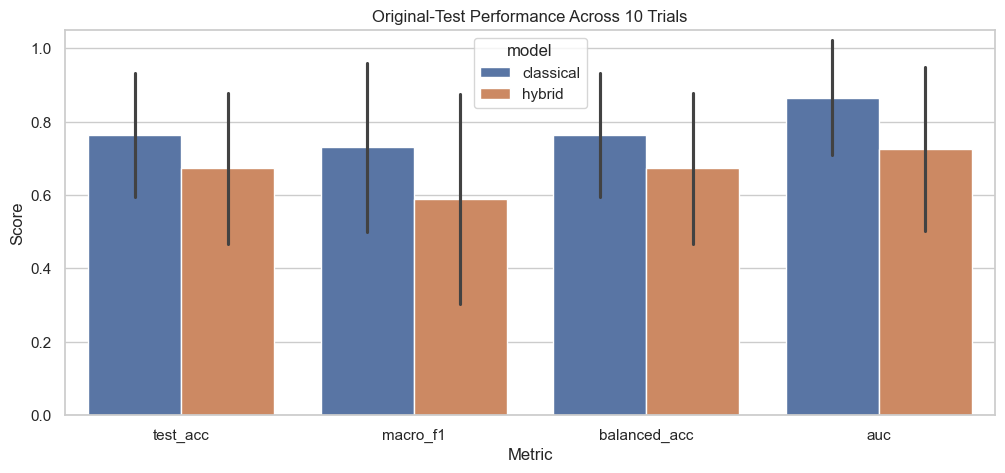

In [42]:
metric_order = ["test_acc", "macro_f1", "balanced_acc", "auc"]
long_final = original_final.melt(
    id_vars=["model", "trial", "seed", "convergence_status"],
    value_vars=metric_order,
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=long_final, x="metric", y="value", hue="model", errorbar="sd")
plt.ylim(0, 1.05)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Original-Test Performance Across 10 Trials")
plt.show()

## Convergence And Failure Analysis

A trial is marked stuck when final original-test macro F1 is near chance or balanced accuracy remains near 0.50.

In [43]:
trial_table_cols = [
    "model", "trial", "seed", "test_loss", "test_acc", "macro_f1", "balanced_acc",
    "auc", "sensitivity", "specificity", "tn", "fp", "fn", "tp", "convergence_status",
]
original_final[trial_table_cols].sort_values(["model", "trial"]).reset_index(drop=True)

,model,trial,seed,test_loss,test_acc,macro_f1,balanced_acc,auc,sensitivity,specificity,tn,fp,fn,tp,convergence_status
0,classical,1.0,42.0,0.121006,0.968750,0.968719,0.968750,0.997070,1.00000,0.93750,30.0,2.0,0.0,32.0,converged
1,classical,2.0,43.0,0.572315,0.796875,0.796825,0.796875,0.842773,0.81250,0.78125,25.0,7.0,6.0,26.0,converged
2,classical,3.0,44.0,0.417808,0.937500,0.937500,0.937500,0.980469,0.93750,0.93750,30.0,2.0,2.0,30.0,converged
3,classical,4.0,45.0,0.614195,0.656250,0.655914,0.656250,0.698242,0.68750,0.62500,20.0,12.0,10.0,22.0,converged
4,classical,5.0,46.0,0.213237,0.937500,0.937500,0.937500,0.977539,0.93750,0.93750,30.0,2.0,2.0,30.0,converged
5,classical,6.0,47.0,0.701760,0.500000,0.333333,0.500000,0.500000,1.00000,0.00000,0.0,32.0,0.0,32.0,stuck
6,classical,7.0,48.0,0.614260,0.500000,0.333333,0.500000,0.955078,1.00000,0.00000,0.0,32.0,0.0,32.0,stuck
7,classical,8.0,49.0,0.588921,0.765625,0.760897,0.765625,0.929688,0.90625,0.62500,20.0,12.0,3.0,29.0,converged
8,classical,9.0,50.0,0.569995,0.765625,0.765109,0.765625,0.884766,0.71875,0.81250,26.0,6.0,9.0,23.0,converged
9,classical,10.0,51.0,0.526421,0.812500,0.809524,0.812500,0.893555,0.93750,0.68750,22.0,10.0,2.0,30.0,converged


In [44]:
failure_summary = (
    original_final.assign(stuck=original_final["convergence_status"].eq("stuck"))
    .groupby("model")
    .agg(
        trials=("trial", "nunique"),
        stuck_trials=("stuck", "sum"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_balanced_acc=("balanced_acc", "mean"),
    )
)
failure_summary["converged_trials"] = failure_summary["trials"] - failure_summary["stuck_trials"]
failure_summary["failure_rate"] = failure_summary["stuck_trials"] / failure_summary["trials"]
failure_summary[["trials", "converged_trials", "stuck_trials", "failure_rate", "mean_macro_f1", "mean_balanced_acc"]].round(4)

,trials,converged_trials,stuck_trials,failure_rate,mean_macro_f1,mean_balanced_acc
model,,,,,,
classical,10,8,2,0.2,0.7299,0.7641
hybrid,10,5,5,0.5,0.5895,0.6734


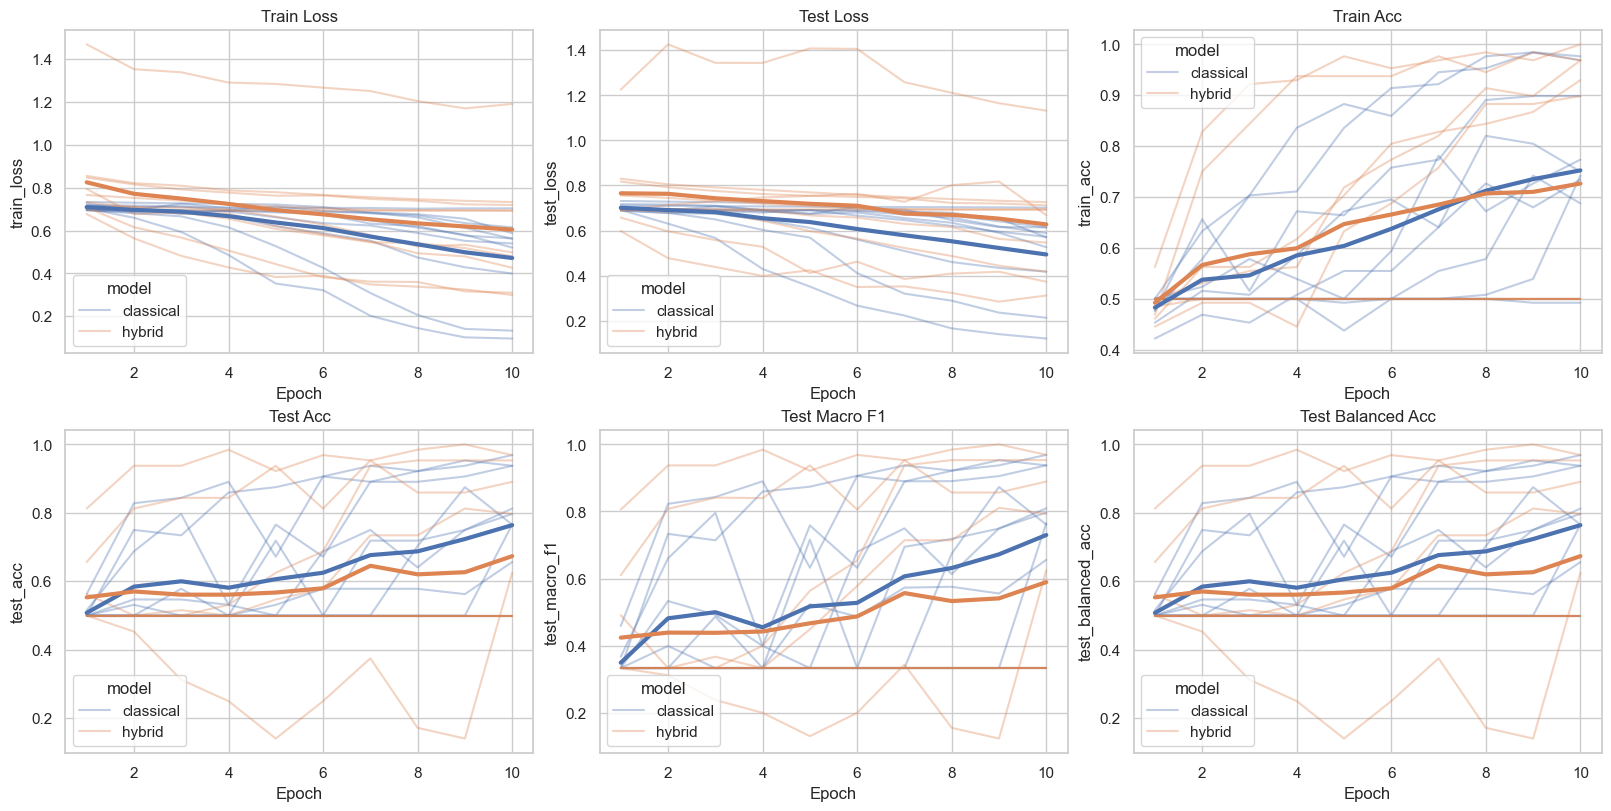

In [45]:
plot_metrics = ["train_loss", "test_loss", "train_acc", "test_acc", "test_macro_f1", "test_balanced_acc"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, metric in zip(axes.flatten(), plot_metrics):
    sns.lineplot(
        data=epoch_df, x="epoch", y=metric, hue="model", units="trial",
        estimator=None, alpha=0.35, ax=ax,
    )
    sns.lineplot(
        data=epoch_df, x="epoch", y=metric, hue="model", estimator="mean",
        errorbar=None, linewidth=3, legend=False, ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Epoch")
plt.show()

## Gradient Diagnostics

This section checks whether stuck hybrid trials failed because QNN gradients collapsed, or whether gradients existed but produced weaker parameter movement.

In [46]:
if diagnostics_df.empty:
    print("Diagnostics CSV not found. Run the hybrid diagnostic experiment to populate this section.")
else:
    hybrid_final_status = (
        original_final[original_final["model"] == "hybrid"]
        [["trial", "seed", "macro_f1", "balanced_acc", "convergence_status"]]
        .rename(columns={
            "macro_f1": "final_macro_f1",
            "balanced_acc": "final_balanced_acc",
            "convergence_status": "final_convergence_status",
        })
    )
    diagnostics_with_status = diagnostics_df.merge(hybrid_final_status, on=["trial", "seed"], how="left")
    diagnostic_cols = [
        "qnn_grad_norm", "qnn_weight_update_norm",
        "fc2_grad_norm", "fc2_weight_update_norm",
        "fc3_grad_norm", "fc3_weight_update_norm",
    ]
    diagnostic_summary = diagnostics_with_status.groupby("final_convergence_status")[diagnostic_cols].agg(["mean", "median", "std"])
    display(diagnostic_summary.round(6))

qnn_grad_norm                      \
                                  mean    median       std   
final_convergence_status                                     
converged                     0.181604  0.177254  0.072455   
stuck                         0.206458  0.176754  0.112564   

                         qnn_weight_update_norm                      \
                                           mean    median       std   
final_convergence_status                                              
converged                              0.001158  0.001087  0.000547   
stuck                                  0.000943  0.001068  0.000420   

                         fc2_grad_norm                      \
                                  mean    median       std   
final_convergence_status                                     
converged                     1.203289  1.172678  0.318237   
stuck                         0.798300  0.600668  0.551594   

                         fc2_weight_update_norm                      \
                                           mean    median       std   
final_convergence_status                                              
converged                              0.000909  0.000772  0.000388   
stuck                                  0.000683  0.000642  0.000391   

                         fc3_grad_norm                      \
                                  mean    median       std   
final_convergence_status                                     
converged                     0.359117  0.370197  0.063847   
stuck                         0.520833  0.475335  0.215935   

                         fc3_weight_update_norm                      
                                           mean    median       std  
final_convergence_status                                             
converged                              0.000904  0.001065  0.000385  
stuck                                  0.000795  0.000902  0.000366

In [47]:
if not diagnostics_df.empty:
    final_epoch_summary = (
        diagnostics_with_status[diagnostics_with_status["epoch"] == diagnostics_with_status["epoch"].max()]
        .groupby("final_convergence_status")[diagnostic_cols]
        .mean()
        .round(6)
    )
    final_epoch_summary

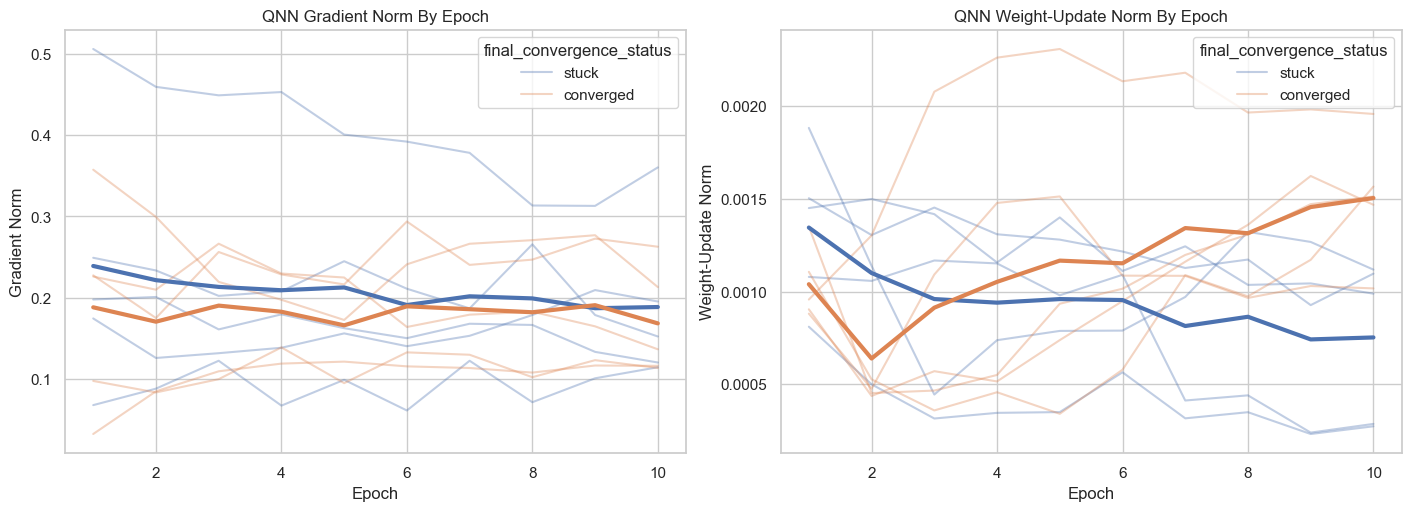

In [48]:
if not diagnostics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    sns.lineplot(
        data=diagnostics_with_status, x="epoch", y="qnn_grad_norm",
        hue="final_convergence_status", units="trial", estimator=None,
        alpha=0.35, ax=axes[0],
    )
    sns.lineplot(
        data=diagnostics_with_status, x="epoch", y="qnn_grad_norm",
        hue="final_convergence_status", estimator="mean", errorbar=None,
        linewidth=3, legend=False, ax=axes[0],
    )
    axes[0].set_title("QNN Gradient Norm By Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Gradient Norm")
    sns.lineplot(
        data=diagnostics_with_status, x="epoch", y="qnn_weight_update_norm",
        hue="final_convergence_status", units="trial", estimator=None,
        alpha=0.35, ax=axes[1],
    )
    sns.lineplot(
        data=diagnostics_with_status, x="epoch", y="qnn_weight_update_norm",
        hue="final_convergence_status", estimator="mean", errorbar=None,
        linewidth=3, legend=False, ax=axes[1],
    )
    axes[1].set_title("QNN Weight-Update Norm By Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Weight-Update Norm")
    plt.show()

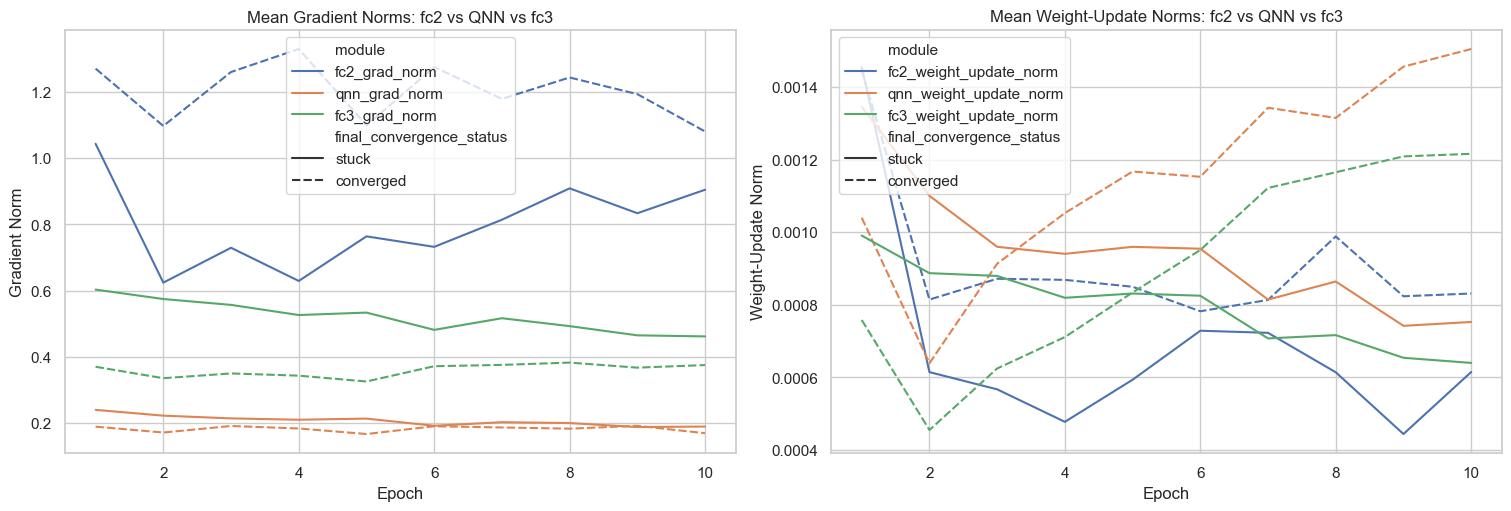

In [49]:
if not diagnostics_df.empty:
    grad_long = diagnostics_with_status.melt(
        id_vars=["trial", "seed", "epoch", "final_convergence_status"],
        value_vars=["fc2_grad_norm", "qnn_grad_norm", "fc3_grad_norm"],
        var_name="module", value_name="gradient_norm",
    )
    update_long = diagnostics_with_status.melt(
        id_vars=["trial", "seed", "epoch", "final_convergence_status"],
        value_vars=["fc2_weight_update_norm", "qnn_weight_update_norm", "fc3_weight_update_norm"],
        var_name="module", value_name="weight_update_norm",
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    sns.lineplot(
        data=grad_long, x="epoch", y="gradient_norm", hue="module",
        style="final_convergence_status", estimator="mean", errorbar=None, ax=axes[0],
    )
    axes[0].set_title("Mean Gradient Norms: fc2 vs QNN vs fc3")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Gradient Norm")
    sns.lineplot(
        data=update_long, x="epoch", y="weight_update_norm", hue="module",
        style="final_convergence_status", estimator="mean", errorbar=None, ax=axes[1],
    )
    axes[1].set_title("Mean Weight-Update Norms: fc2 vs QNN vs fc3")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Weight-Update Norm")
    plt.show()

In [50]:
if not diagnostics_df.empty:
    final_epoch_diagnostics = diagnostics_with_status[
        diagnostics_with_status["epoch"] == diagnostics_with_status["epoch"].max()
    ]
    final_cols = [
        "trial", "seed", "final_convergence_status", "final_macro_f1", "final_balanced_acc",
        "qnn_grad_norm", "qnn_weight_update_norm",
        "fc2_grad_norm", "fc2_weight_update_norm",
        "fc3_grad_norm", "fc3_weight_update_norm",
    ]
    final_epoch_diagnostics[final_cols].sort_values(["final_convergence_status", "trial"]).reset_index(drop=True).round(6)

## Learning-Rate Sweep

This optional section appears after running the hybrid-only sweep for learning rates `0.0005`, `0.001`, and `0.002`. It tests whether hybrid instability and smaller QNN updates are sensitive to optimizer step size.

In [51]:
if lr_sweep_summary.empty:
    print("Learning-rate sweep summary not found yet. Run experiments/oasis2/oasis2_coronal_lr_sweep.py to populate this section.")
else:
    display(lr_sweep_summary.sort_values("lr").round(6))

,lr,mean_macro_f1,mean_balanced_acc,mean_auc,stuck_trials,converged_trials,failure_rate,mean_qnn_grad_norm,mean_qnn_update_norm,final_epoch_qnn_grad_norm,final_epoch_qnn_update_norm
0,0.0005,0.632869,0.696875,0.821533,3,7,0.3,0.201551,0.000551,0.192148,0.000611
1,0.0010,0.589521,0.673438,0.726074,5,5,0.5,0.194031,0.001051,0.178655,0.001129
2,0.0020,0.639267,0.721875,0.838281,5,5,0.5,0.183791,0.001965,0.166887,0.002113


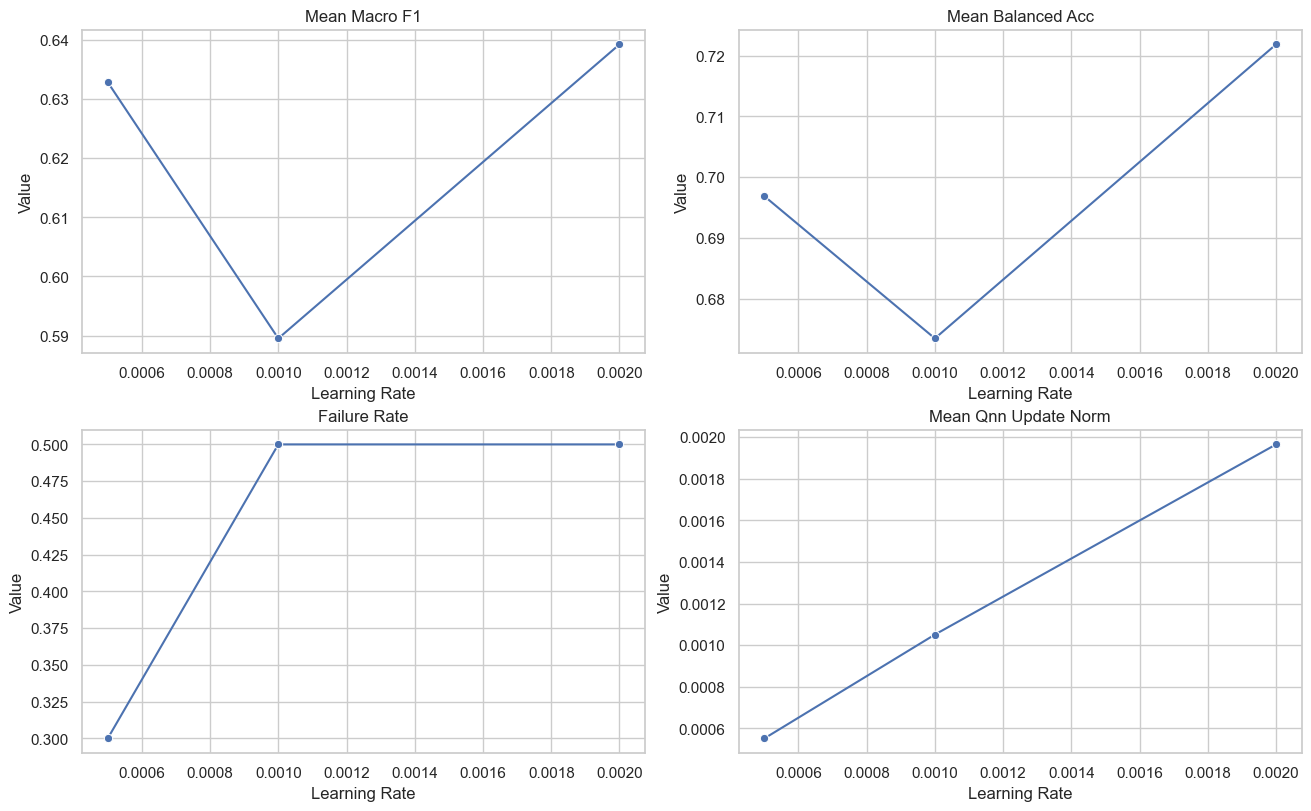

In [52]:
if not lr_sweep_summary.empty:
    sweep_long = lr_sweep_summary.melt(
        id_vars=["lr"],
        value_vars=["mean_macro_f1", "mean_balanced_acc", "failure_rate", "mean_qnn_update_norm"],
        var_name="metric",
        value_name="value",
    )
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    for ax, metric in zip(axes.flatten(), sweep_long["metric"].unique()):
        data = sweep_long[sweep_long["metric"] == metric]
        sns.lineplot(data=data, x="lr", y="value", marker="o", ax=ax)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Learning Rate")
        ax.set_ylabel("Value")
    plt.show()

In [53]:
if not lr_sweep_summary.empty:
    best_by_macro_f1 = lr_sweep_summary.sort_values(
        ["mean_macro_f1", "mean_balanced_acc", "failure_rate"],
        ascending=[False, False, True],
    ).iloc[0]
    best_by_failure_rate = lr_sweep_summary.sort_values(
        ["failure_rate", "mean_macro_f1"],
        ascending=[True, False],
    ).iloc[0]
    print(f"Best LR by macro F1: {best_by_macro_f1.lr:g}")
    print(f"Best LR by failure rate: {best_by_failure_rate.lr:g}")
    if lr_sweep_summary["failure_rate"].nunique() > 1 or lr_sweep_summary["mean_qnn_update_norm"].max() != lr_sweep_summary["mean_qnn_update_norm"].min():
        print("Interpretation: hybrid behavior is learning-rate sensitive; compare update norms and stuck rates before changing architecture.")
    else:
        print("Interpretation: this sweep did not materially change failure rate or QNN update magnitude.")

Best LR by macro F1: 0.002
Best LR by failure rate: 0.0005
Interpretation: hybrid behavior is learning-rate sensitive; compare update norms and stuck rates before changing architecture.


## Conclusion

The 10-trial OASIS-2 coronal experiment supports the paper's broader observation that hybrid classical-quantum models can become stuck during optimization on visually similar medical imaging classes. In the baseline setting, the classical CNN was more stable and achieved higher mean macro F1 and balanced accuracy than the 2-qubit hybrid model. The hybrid model did not fail uniformly: it converged strongly for some seeds, but became stuck near chance-level behavior in half of the trials.

The gradient diagnostics refine the explanation. Stuck hybrid trials did not show complete QNN gradient collapse: their QNN gradient norms were nonzero and were not lower than those of converged trials on average. However, stuck trials showed smaller QNN weight-update magnitudes, especially by the final epoch. This suggests that the failure in this implementation is better described as ineffective quantum parameter optimization rather than simple zero-gradient behavior.

The learning-rate sweep shows that the hybrid behavior is optimizer-sensitive, but not solved by a single LR change. Lowering the learning rate to `0.0005` reduced the stuck-trial rate from 50% to 30%, while increasing the learning rate to `0.002` gave the best mean macro F1 and balanced accuracy but still left 50% of trials stuck. This means learning rate affects the optimization behavior, but architecture or data-representation factors may still be limiting reliability.

Therefore, the current evidence agrees with the paper that the hybrid architecture can struggle to optimize on this task, while adding two nuances: gradient norm alone was not the problem, and QNN parameter movement is sensitive to learning rate. The next controlled step should compare whether a modest architecture or quantum-layer output-scaling change improves reliability beyond what LR tuning can do.